# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Possible Rarities and its order

In [2]:
# Rarity Order for sorting
# Higher value means rarer card
rarityOrder = {
    "Common": 10,
    "Uncommon": 20,
    "Rare": 30,                         # Regular
    "Classic Collection": 31,
    "Rare Holo": 40,                    # Holofoil
    "Double Rare": 50,                  # EX
    "Ultra Rare": 60,                   # Unique card classification
    "Rare Ultra": 60,                   # Unique card classification
    "Rare Holo Star": 61,
    "Rare Prime": 61,
    "Rare Holo LV.X": 61,
    "Rare Holo EX": 61,
    "Rare Holo GX": 61,
    "LEGEND": 61,
    "Rare BREAK": 61,
    "Amazing Rare": 61,
    "Rare Prism Star": 61,
    "Rare ACE": 61,
    "ACE SPEC Rare": 61,
    "Radiant Rare": 62,
    "Rare Holo V": 63,
    "Rare Holo VSTAR": 64,
    "Rare Holo VMAX": 65,
    "Trainer Gallery Rare Holo": 66,
    "Rare Secret": 70,                  # Out of numbers
    "Rare Shining": 71,                 # Shiny Pokemon
    "Shiny Rare": 72,                   # Shiny Pokemon
    "Rare Shiny": 72,                   # Shiny Pokemon
    "Rare Shiny GX": 73,                # Shiny Pokemon
    "Shiny Ultra Rare": 73,             # Shiny Pokemon
    "Rare Rainbow": 74,
    "Illustration Rare": 75,            # Full-Art
    "Special Illustration Rare": 76,    # Full-Art
    "Hyper Rare": 80,                   # Gold Cards
    "Promo": 90                         # Event Cards
}

# List of grade order
# Number has no meaning
gradeOrder = {
    'holo-nearmint': 1,
    'holo-good': 2,
    'holo-played': 3,
    'holo-used' : 4, 
    'holo-poor': 5,
    'reverse-nearmint': 6,
    'reverse-good': 7,
    'reverse-played': 8,
    'reverse-used': 9,
    'reverse-poor': 10,
    'normal-nearmint': 11,
    'normal-good': 12,
    'normal-played': 13,
    'normal-used': 14,
    'normal-poor': 15
}

# Dataframe

In [3]:
# Read data
df = pd.read_csv('merged_pokemon_data.csv')

# Process Data
df['Month'] = pd.to_datetime(df['Month'], errors='coerce')
df['Month'] = df['Month'].dt.strftime('%Y-%m')
df = df.sort_values('Month')

df['Average'] = pd.to_numeric(df['Average'], errors='coerce')

# Sort the unique rarities in the DataFrame using rarityOrder
sorted_rarities = sorted(df['Rarity'].dropna().unique(), key=lambda r: rarityOrder.get(r, float('inf')), reverse=True)
sorted_grades = sorted(df['Grade'].dropna().unique(), key=lambda r: gradeOrder.get(r, float('inf')), reverse=False)


# Heatmaps

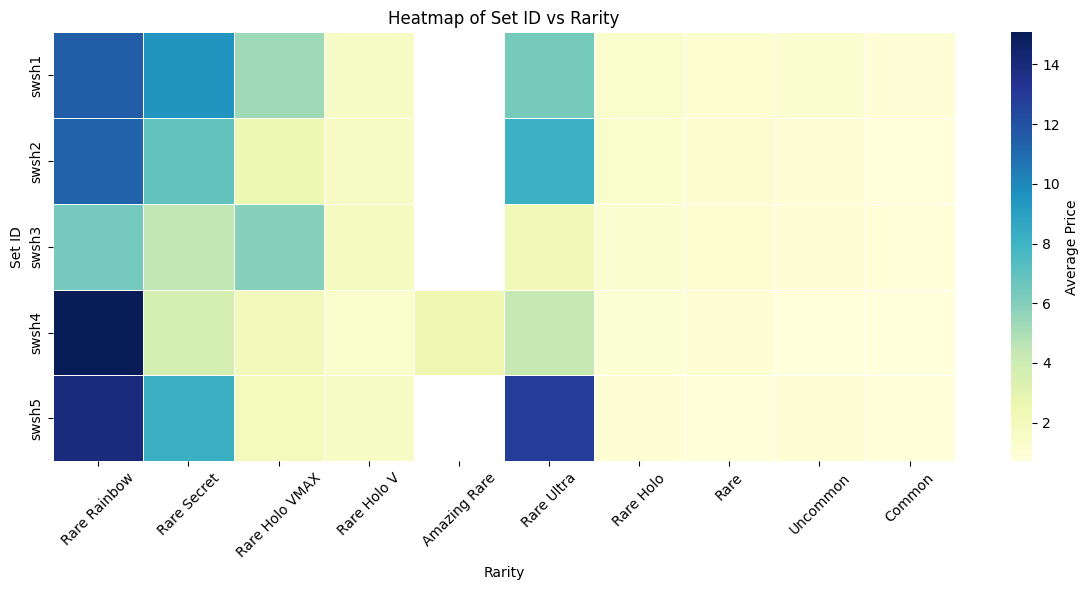

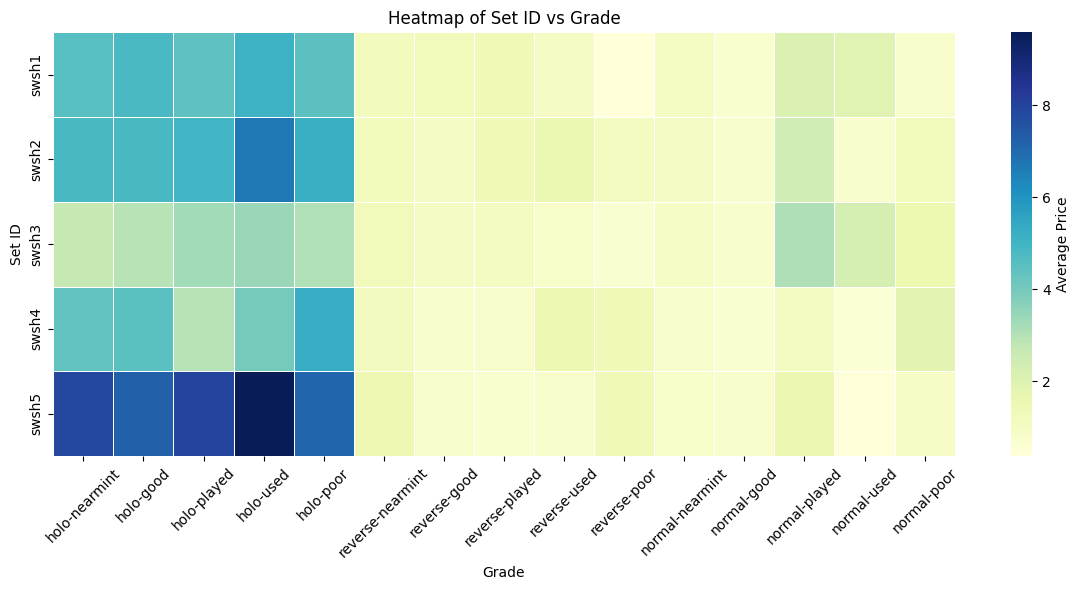

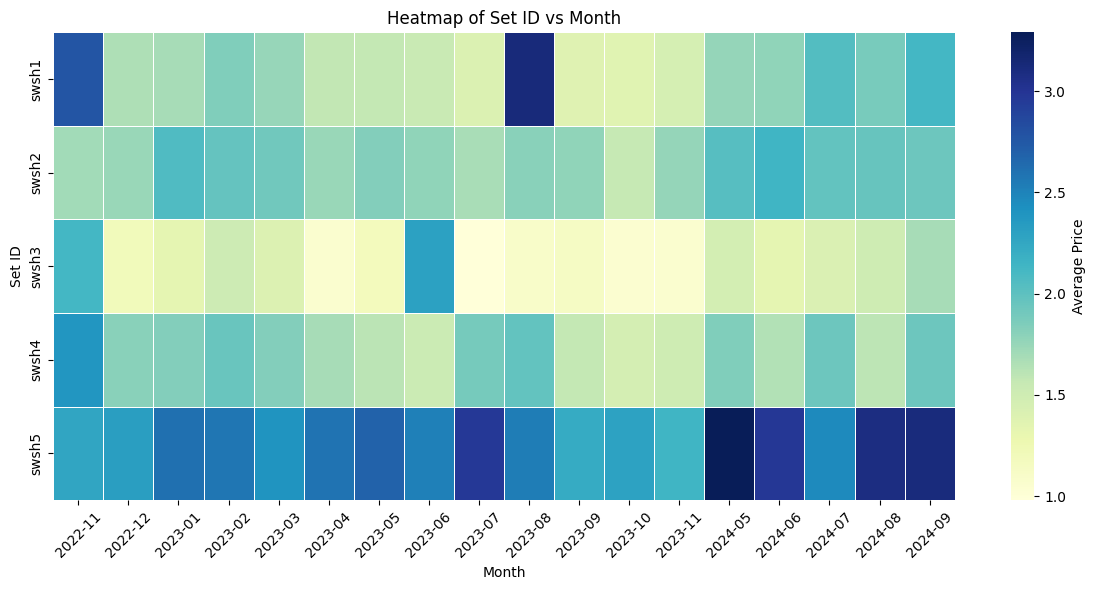

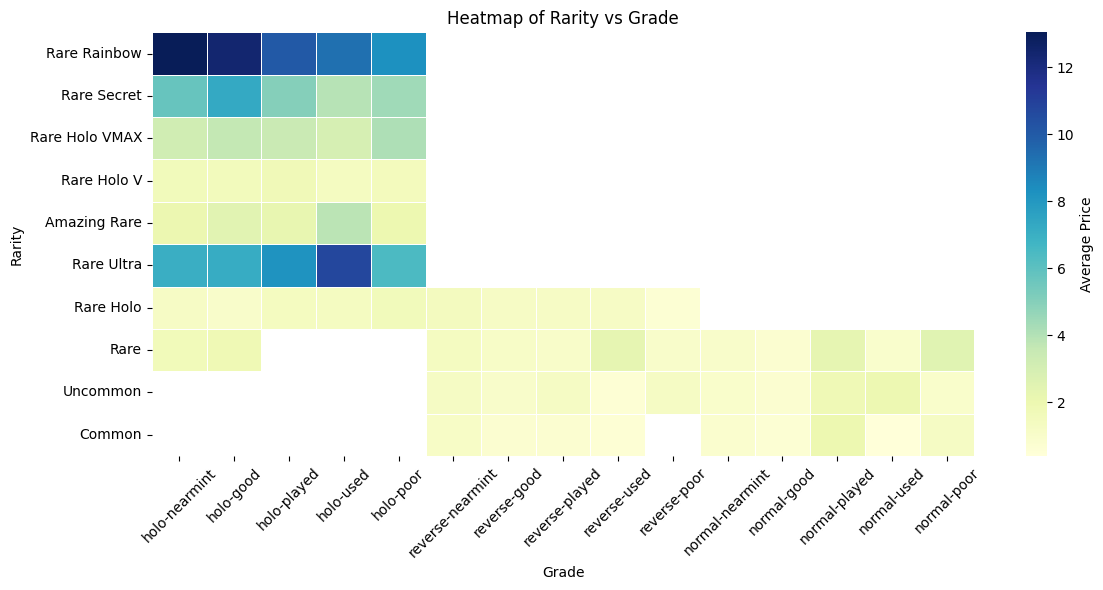

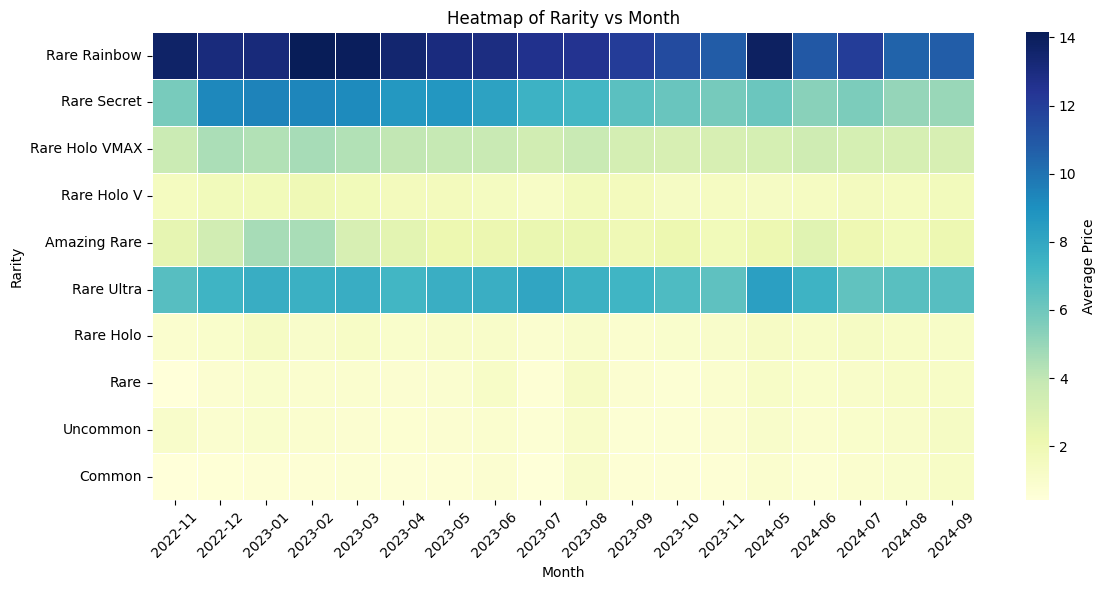

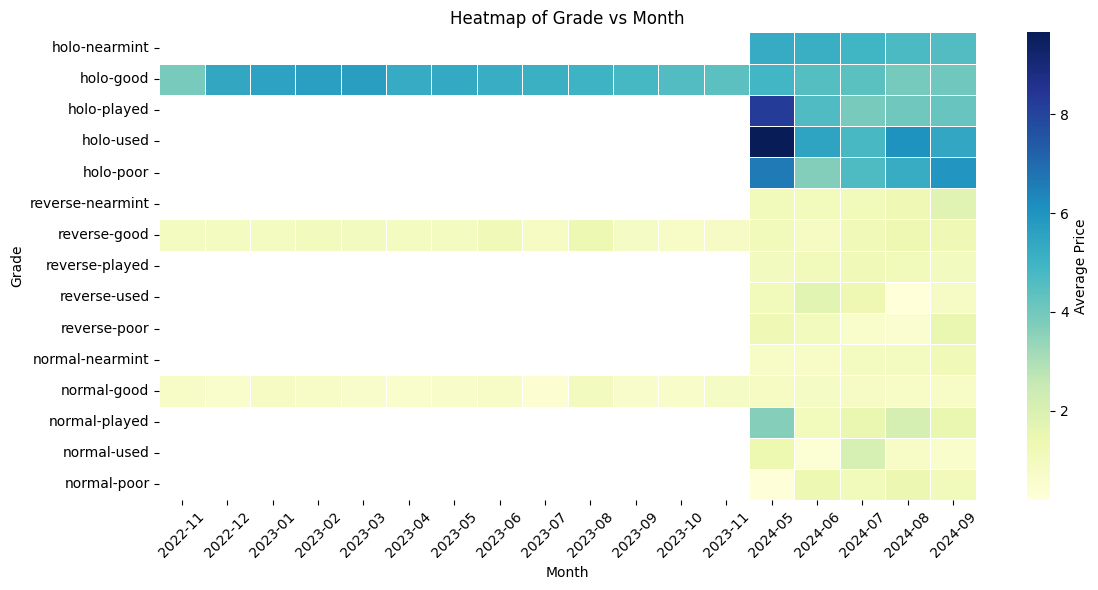

In [4]:
# List of heatmap pairs
heatmap_combos = [
    ('Set ID', 'Rarity'),
    ('Set ID', 'Grade'),
    ('Set ID', 'Month'),
    ('Rarity', 'Grade'),
    ('Rarity', 'Month'),
    ('Grade', 'Month'),
]

for row_attr, col_attr in heatmap_combos:
    pivot_table = df.pivot_table(index=row_attr, columns=col_attr, values='Average', aggfunc='mean')
    pivot_table = pivot_table.div(100).round(2)

    # Sort based on Rarity if it's in the rows or columns
    if row_attr == 'Rarity':
        pivot_table = pivot_table.loc[sorted_rarities]
    if col_attr == 'Rarity':
        pivot_table = pivot_table[sorted_rarities]

    # Sort based on Grade if it's in the rows or columns
    if row_attr == 'Grade':
        pivot_table = pivot_table.loc[sorted_grades]
    if col_attr == 'Grade':
        pivot_table = pivot_table[sorted_grades]

    # Plot
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, annot=False, cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'Average Price'})
    plt.title(f'Heatmap of {row_attr} vs {col_attr}')
    plt.ylabel(row_attr)
    plt.xlabel(col_attr)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Scatterplots

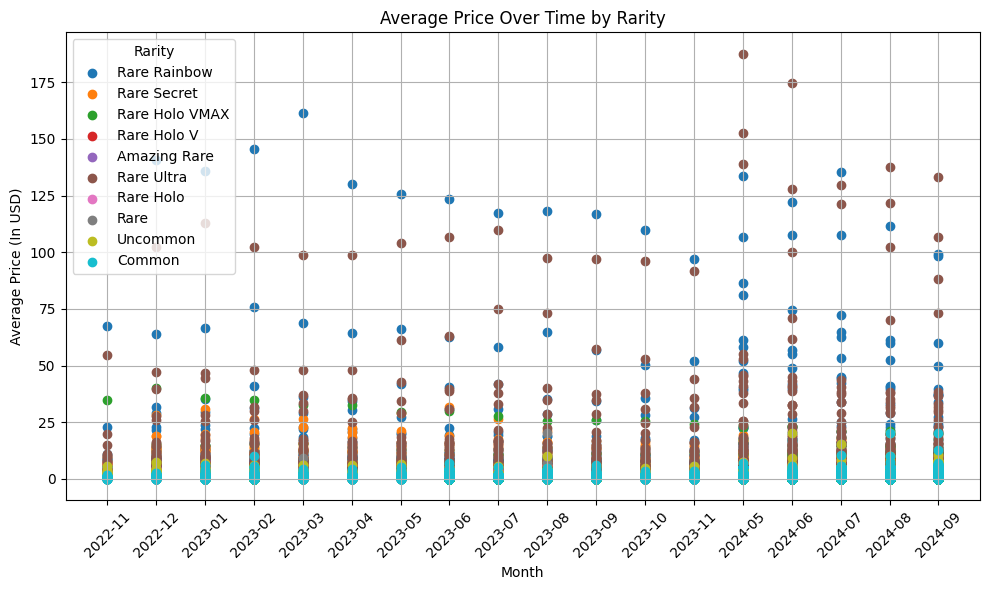

In [5]:
# Process Data
plt.figure(figsize=(10, 6))
dfs_by_rarity = []
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]
    dfs_by_rarity.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=rarity, marker='o')

# Set graph title and labels
plt.title('Average Price Over Time by Rarity')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Rarity')
plt.grid(True)
plt.tight_layout()

plt.show()


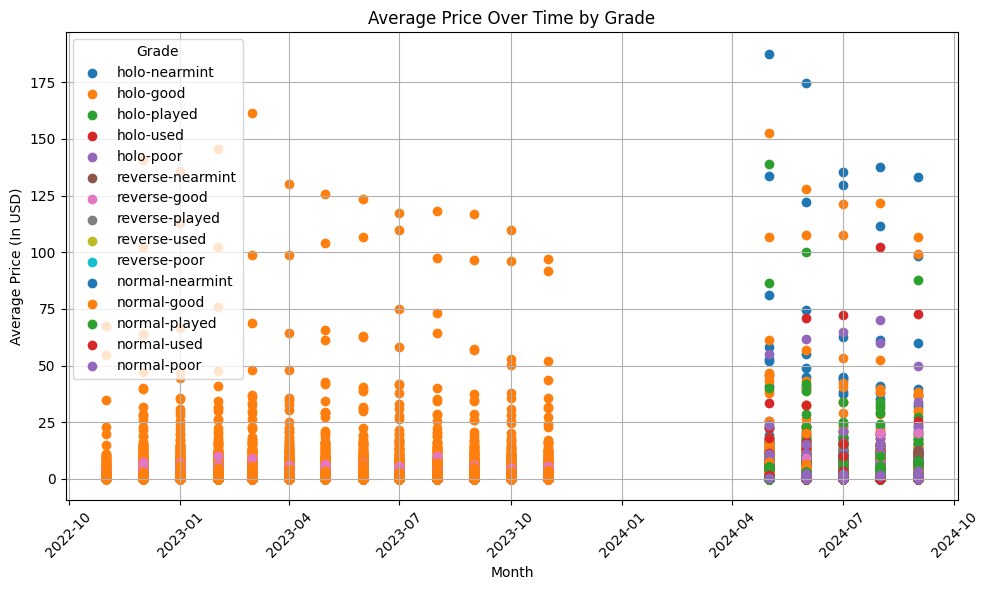

In [6]:
# Load and prepare data
df_sub = pd.read_csv('merged_pokemon_data.csv')
df_sub['Month'] = pd.to_datetime(df_sub['Month'], errors='coerce')
df_sub = df_sub.sort_values('Month')

# Process Data
plt.figure(figsize=(10, 6))
dfs_by_grade = []

for grade in sorted_grades:
    subset = df_sub[df_sub['Grade'] == grade]
    dfs_by_grade.append(subset)
    plt.scatter(subset['Month'], subset['Average'].div(100).round(2), label=grade, marker='o')

# Plot
plt.title('Average Price Over Time by Grade')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.legend(title='Grade')
plt.grid(True)
plt.tight_layout()

# Format x-axis as "YYYY-MM"
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))

plt.show()


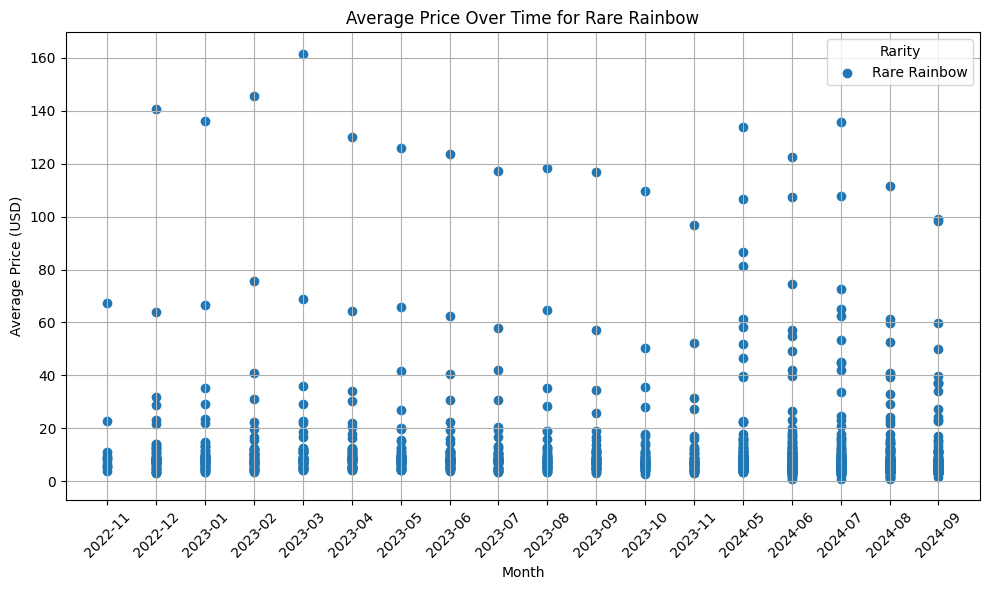

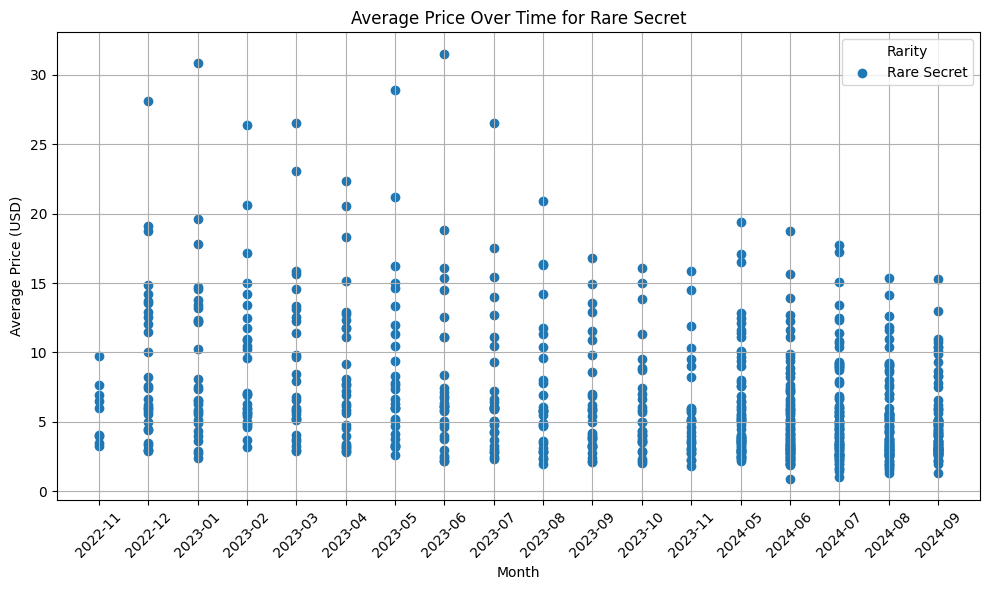

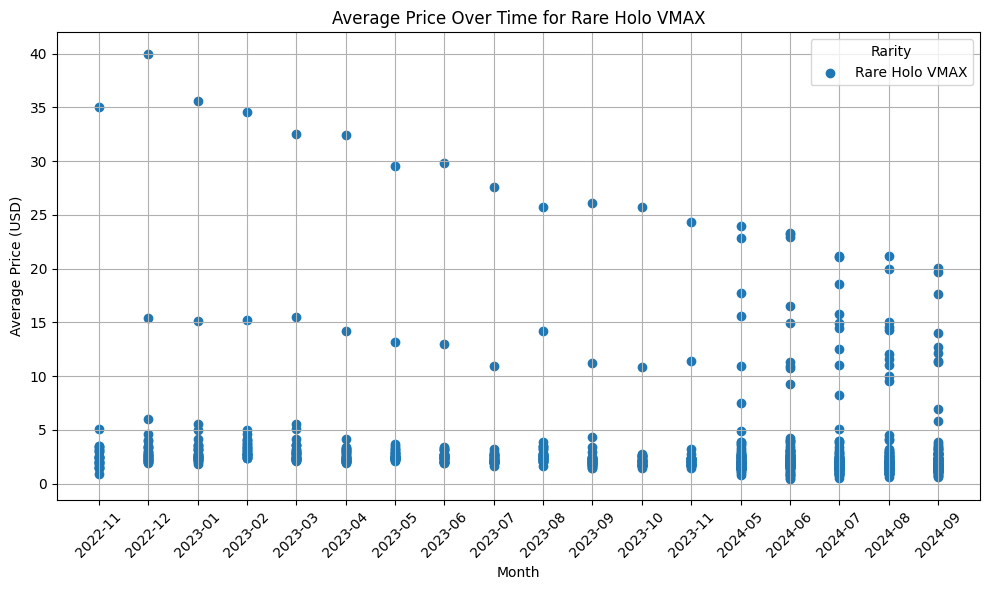

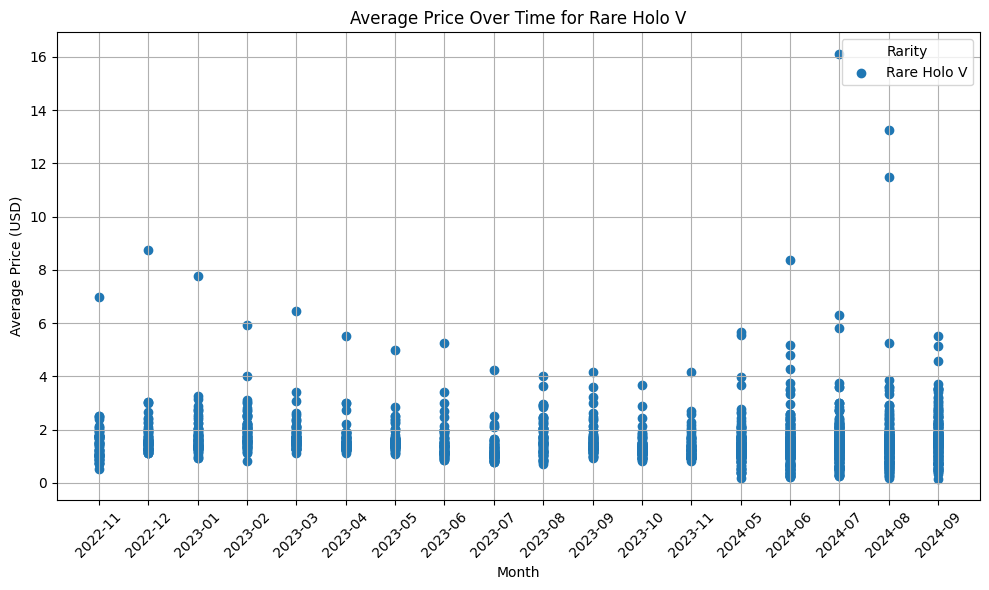

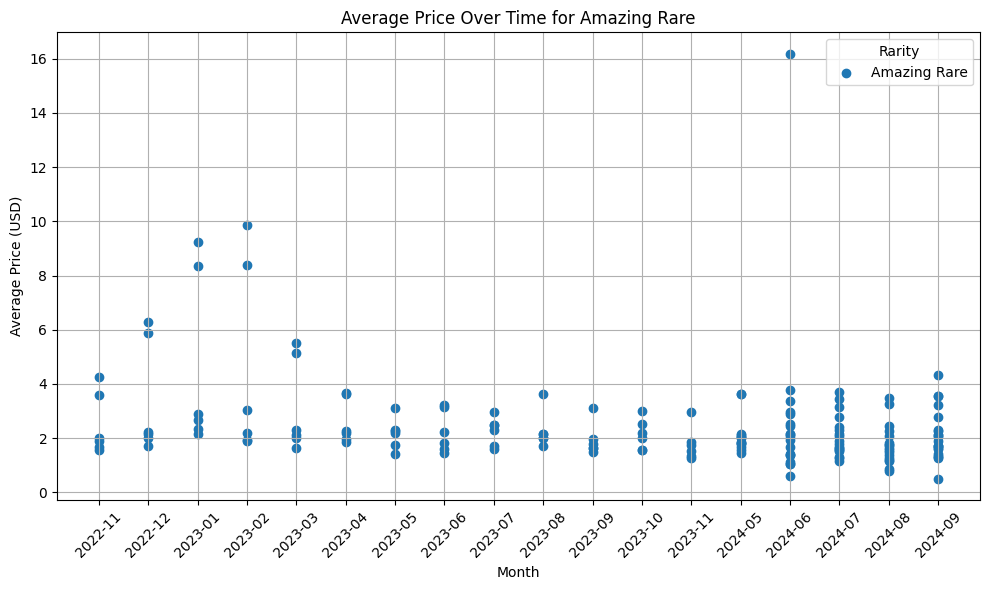

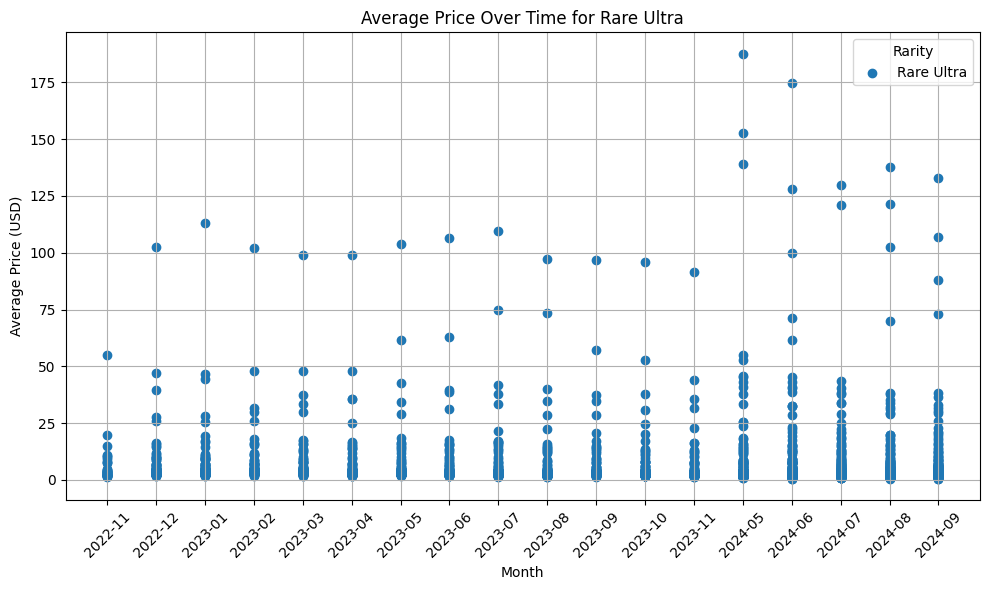

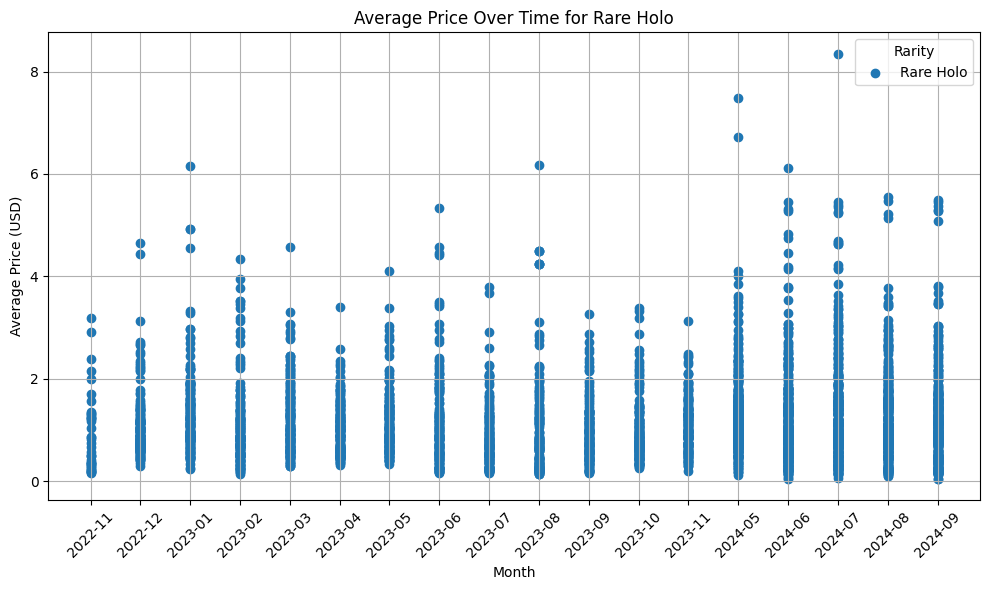

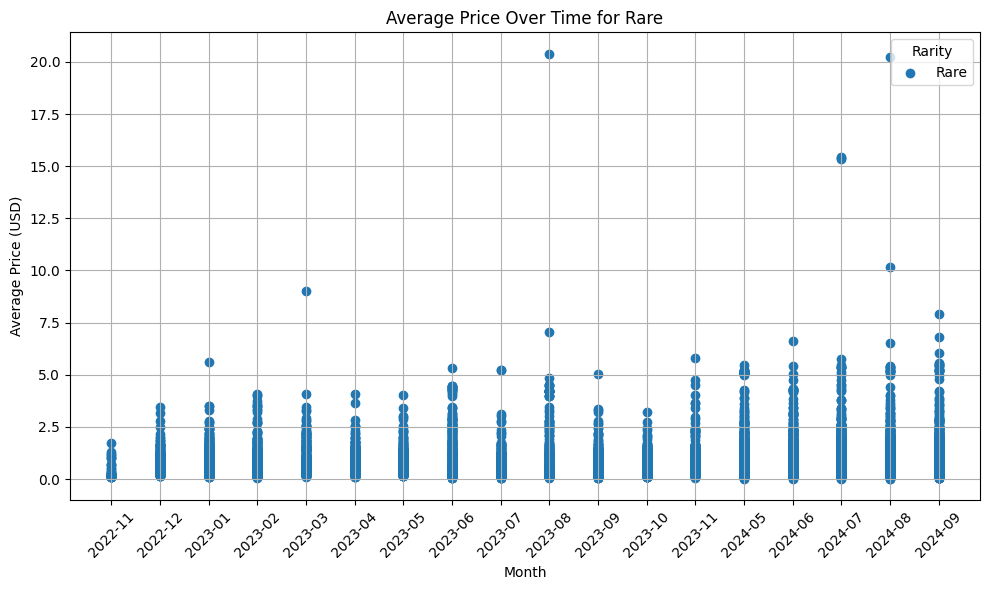

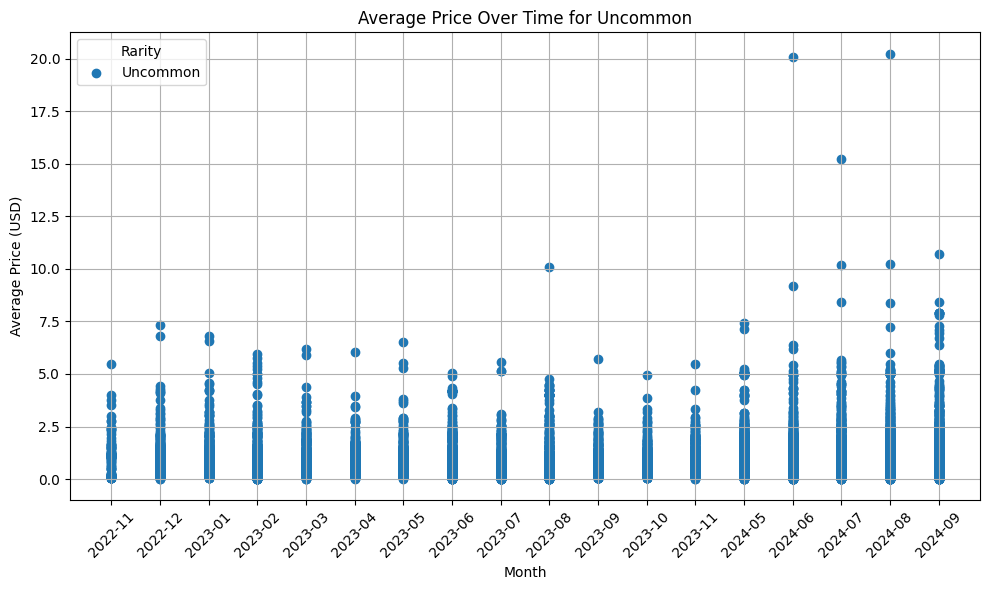

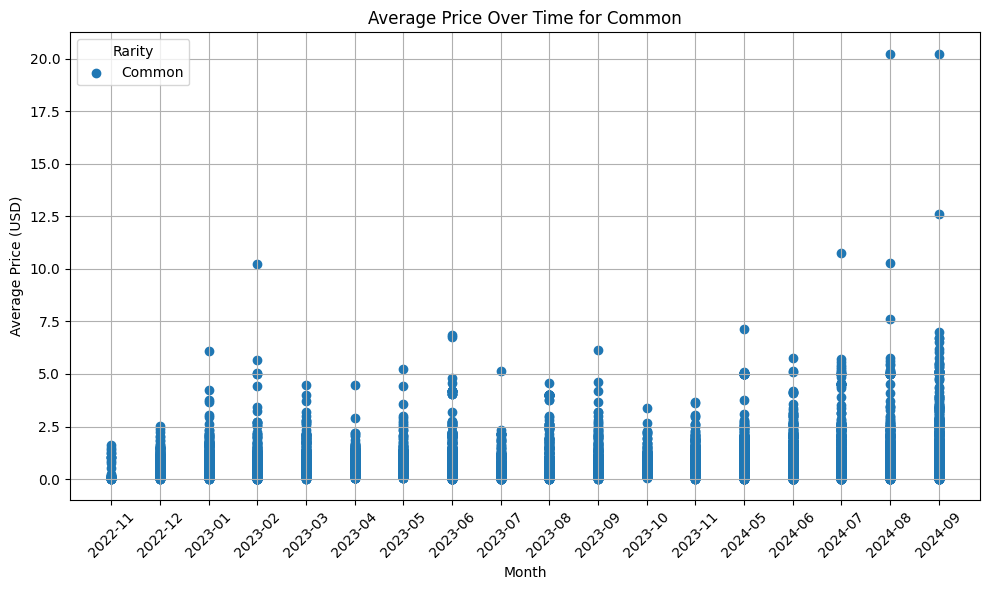

In [7]:
# Loop over each Rarity
for rarity in sorted_rarities:
    # Filter data for the current rarity
    subset = df[df['Rarity'] == rarity].sort_values(by='Month')
    
    # Create a new figure
    plt.figure(figsize=(10, 6))
    
    # Plot scatter plot
    plt.scatter(
        subset['Month'],
        subset['Average'] / 100,  # Convert cents to dollars
        label=rarity,
        marker='o'
    )
    
    # Plot
    plt.title(f'Average Price Over Time for {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (USD)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Rarity')
    plt.tight_layout()
    plt.show()


# Boxplots

C:\Users\jiunk\AppData\Local\Temp\ipykernel_29040\3690359875.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\jiunk\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


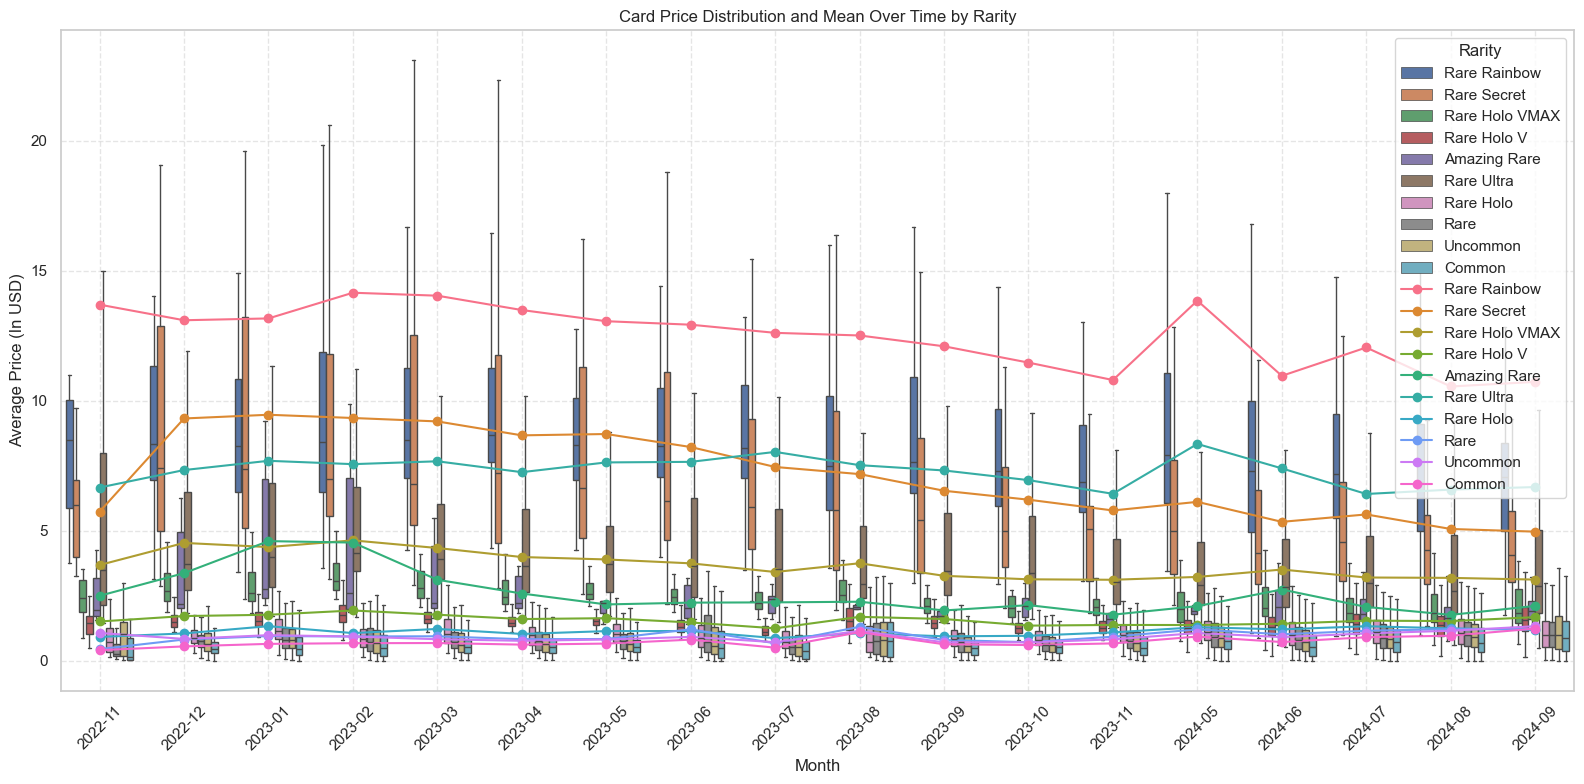

In [8]:
# Set style
sns.set(style='whitegrid')

plt.figure(figsize=(16, 8))

# Boxplot (all data combined)
sns.boxplot(
    data=df, 
    x=df['Month'] , 
    y=df['Average'] / 100, 
    hue='Rarity', 
    hue_order=sorted_rarities,
    showfliers=False,
    dodge=True, 
    linewidth=1
)

# Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

# Customize plot
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


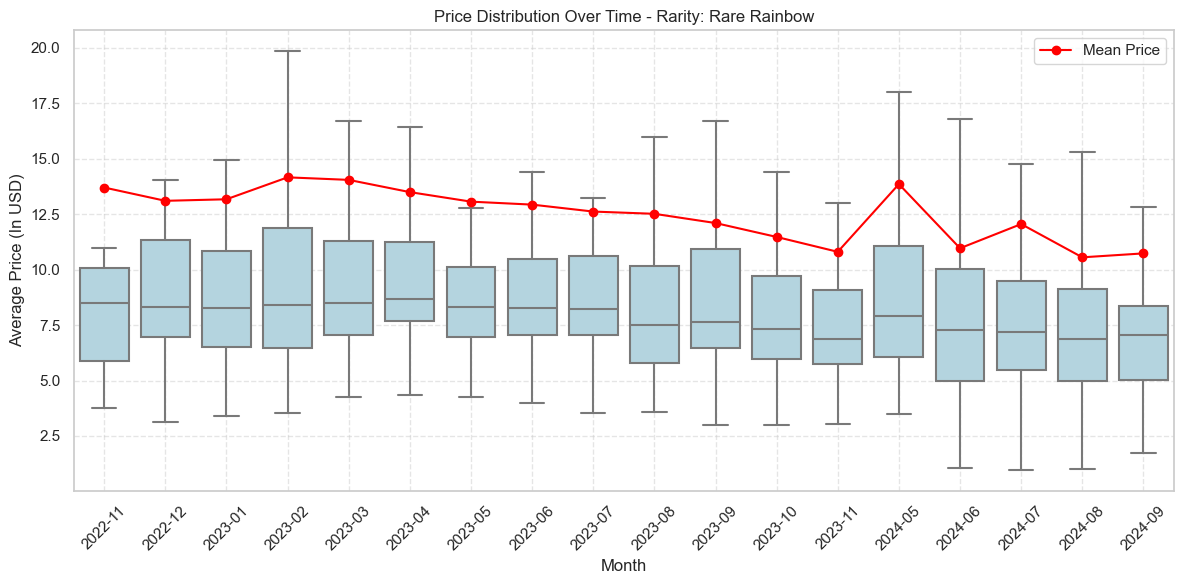

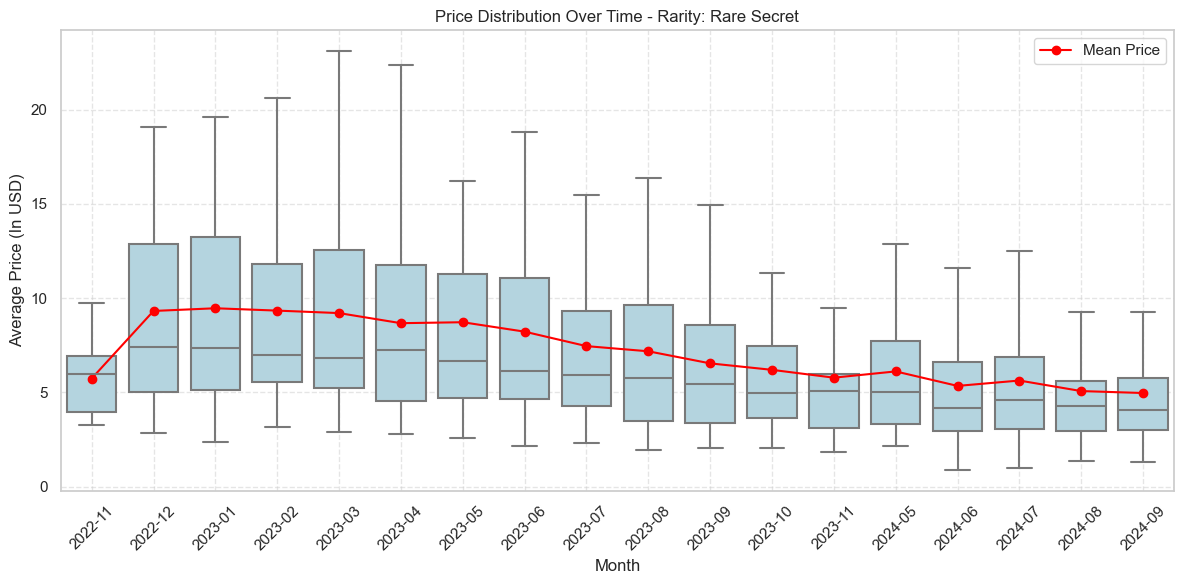

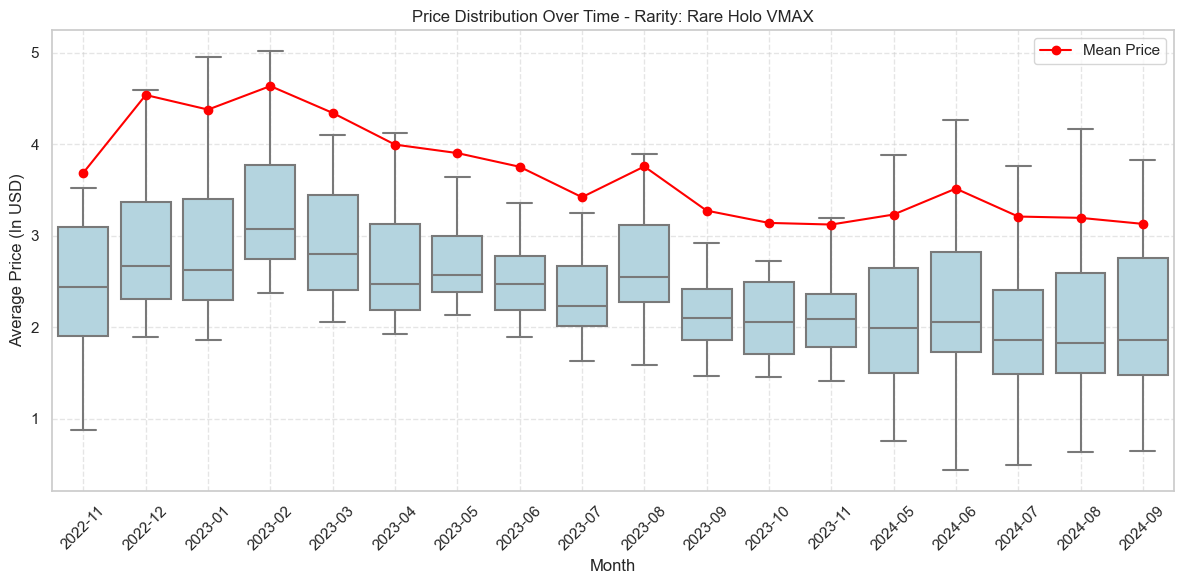

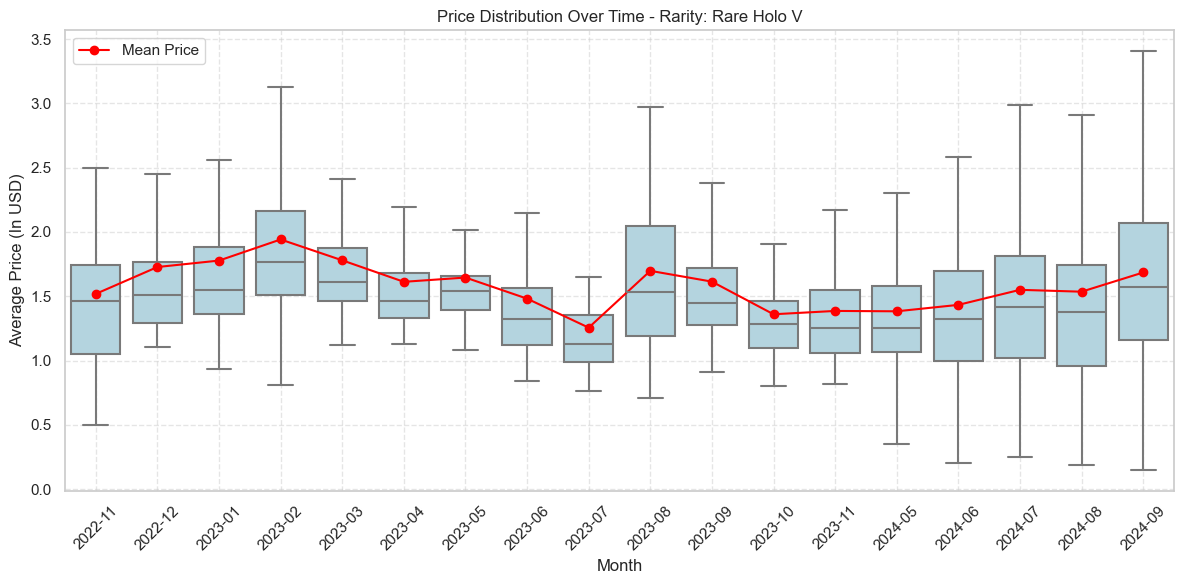

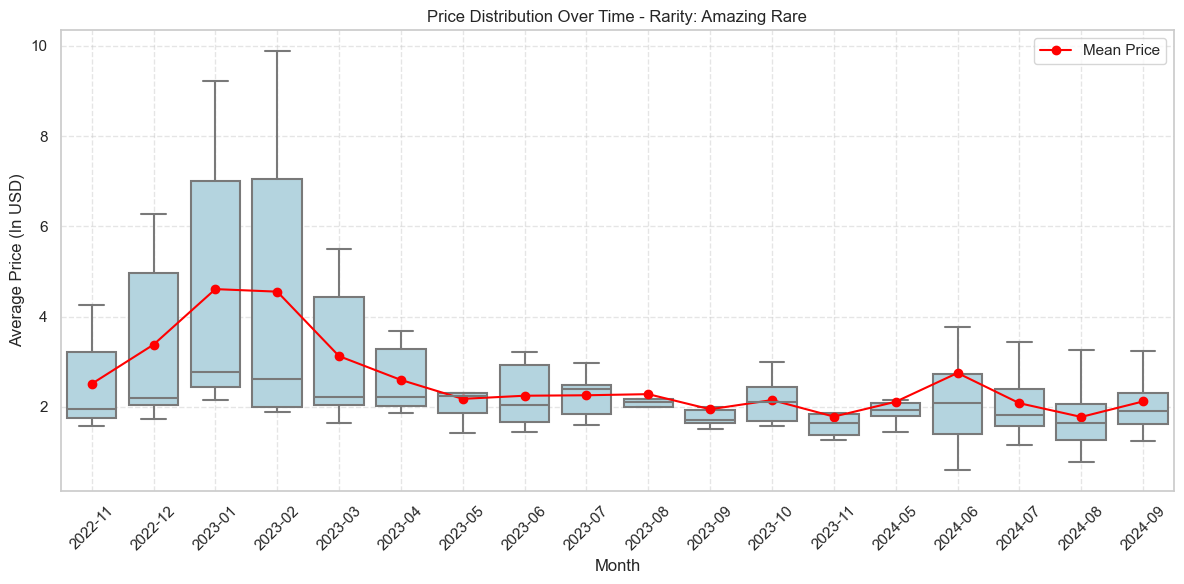

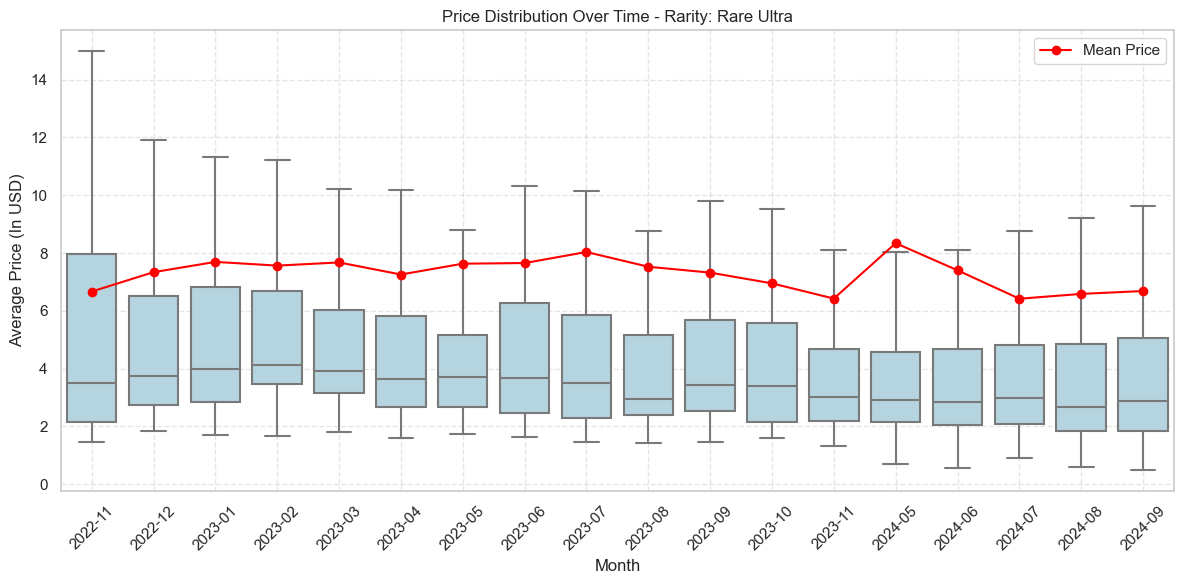

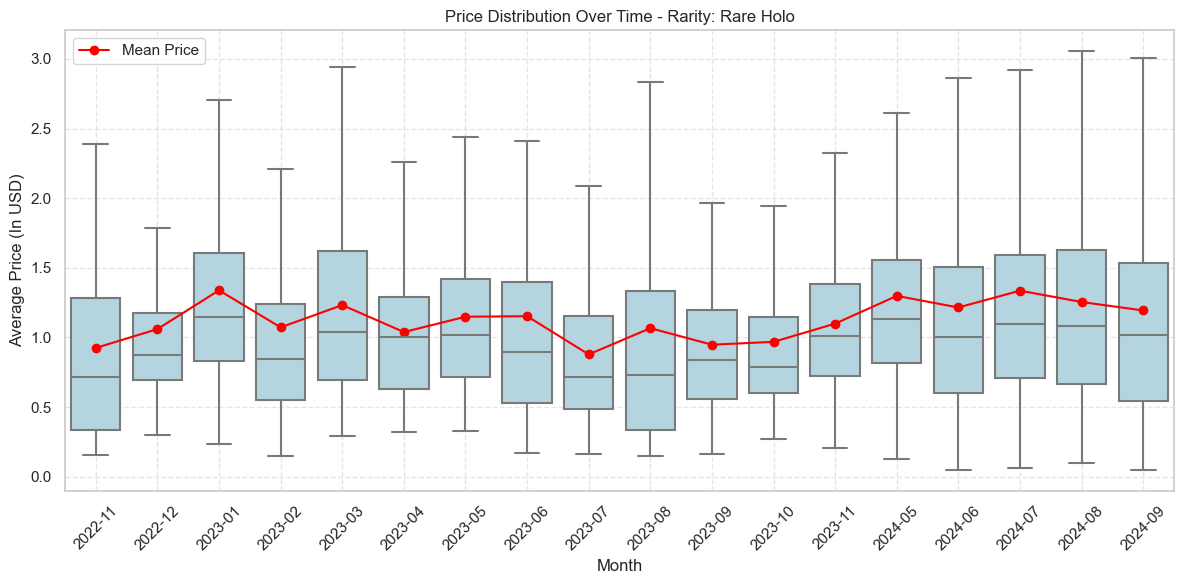

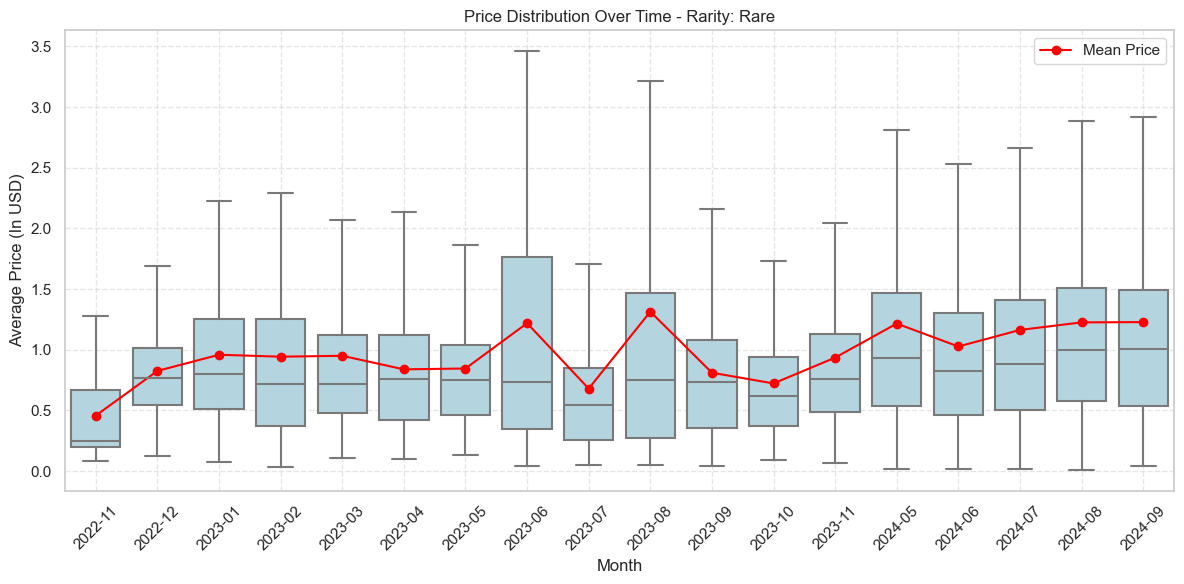

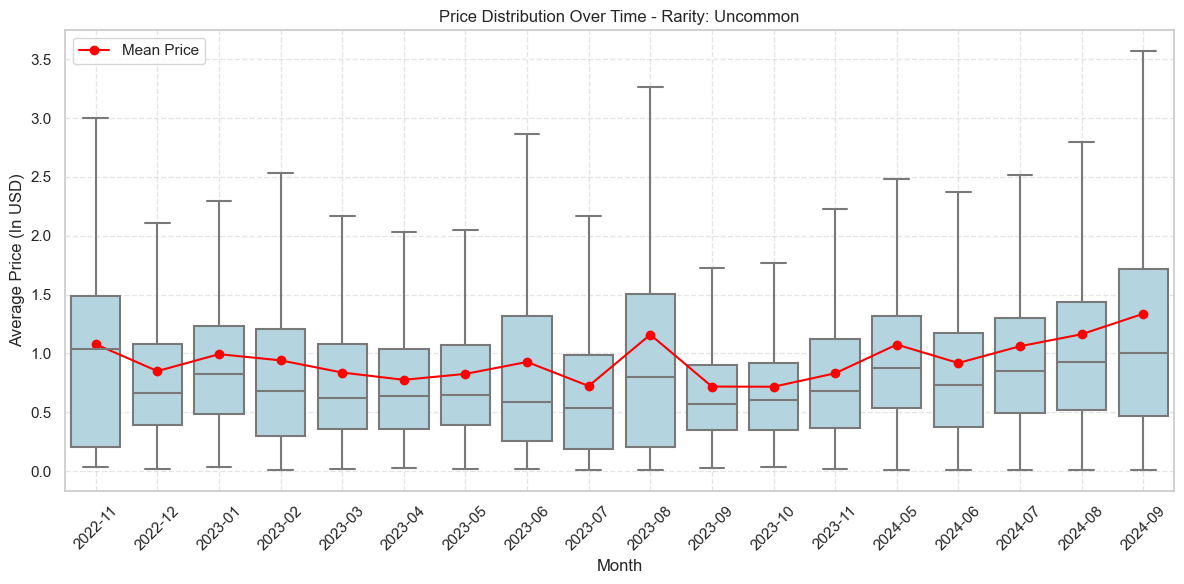

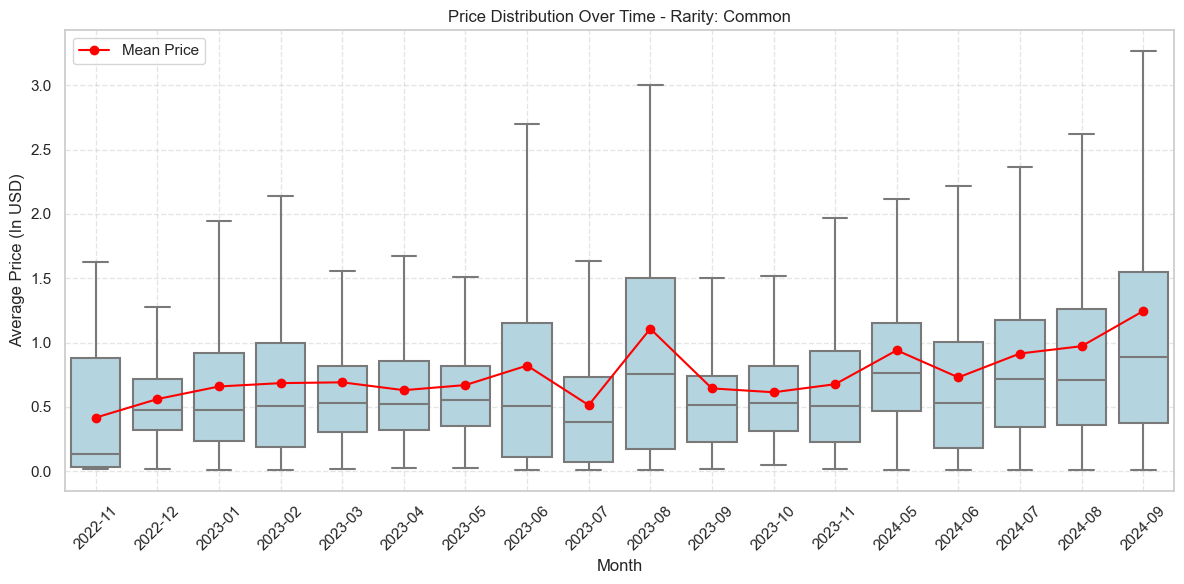

In [9]:
# Graph Style
sns.set(style='whitegrid')

# Plot for each rarity
for rarity in sorted_rarities:
    subset = df[df['Rarity'] == rarity]

    plt.figure(figsize=(12, 6))
    
    # Boxplot of all card prices for each month
    sns.boxplot(data=subset, x=df['Month'], y=subset['Average'] / 100, color='lightblue', showfliers=False)
    
    # Line plot of mean prices per month
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, color='red', marker='o', label='Mean Price')

    # Plots
    plt.title(f'Price Distribution Over Time - Rarity: {rarity}')
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()


# Line graphs

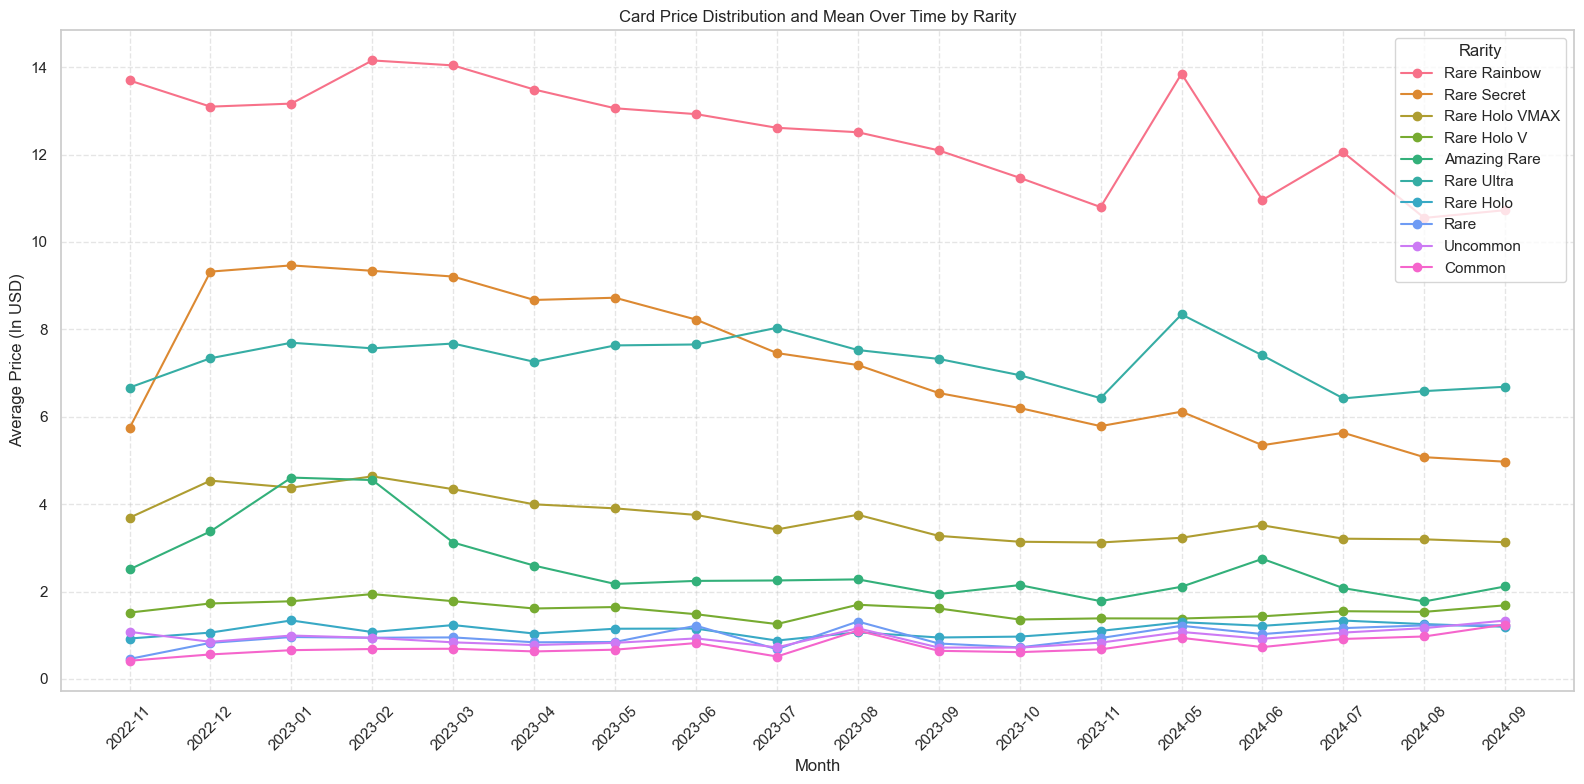

In [10]:
# Graph style
sns.set(style='whitegrid')
plt.figure(figsize=(16, 8))

# Mean line per rarity
palette = sns.color_palette("husl", len(sorted_rarities))
for rarity, color in zip(sorted_rarities, palette):
    subset = df[df['Rarity'] == rarity]
    mean_per_month = subset.groupby('Month')['Average'].mean() / 100
    plt.plot(mean_per_month.index, mean_per_month.values, label=rarity, color=color, marker='o')

# Plot Line Graphs
plt.title('Card Price Distribution and Mean Over Time by Rarity')
plt.xlabel('Month')
plt.ylabel('Average Price (In USD)')
plt.xticks(rotation=45)
plt.legend(title='Rarity')
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


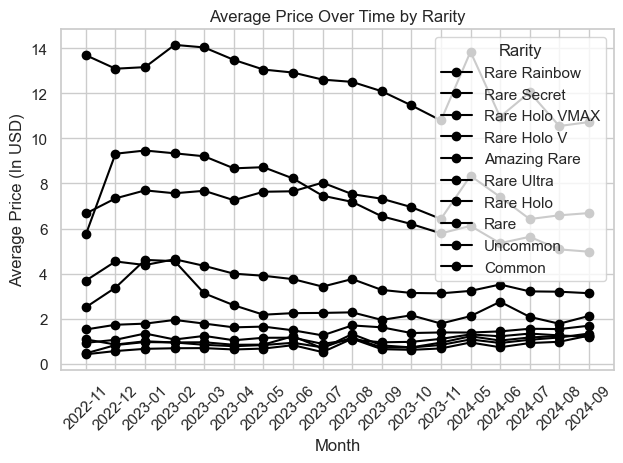

In [11]:
for rarity_df in dfs_by_rarity:
    # print(rarity_df.columns)
    # Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    # print(months)
    # Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    # lists = sorted(itertools.izip(*[]))
    # plt.figure()
    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
plt.show()

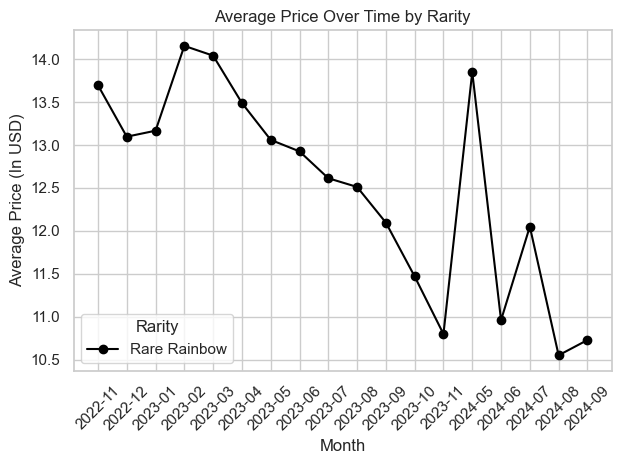

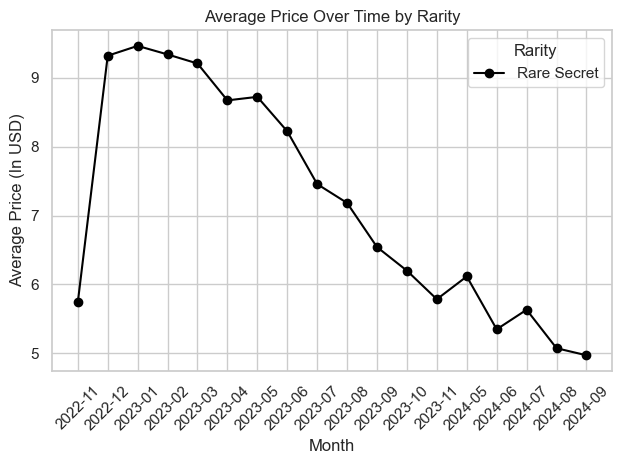

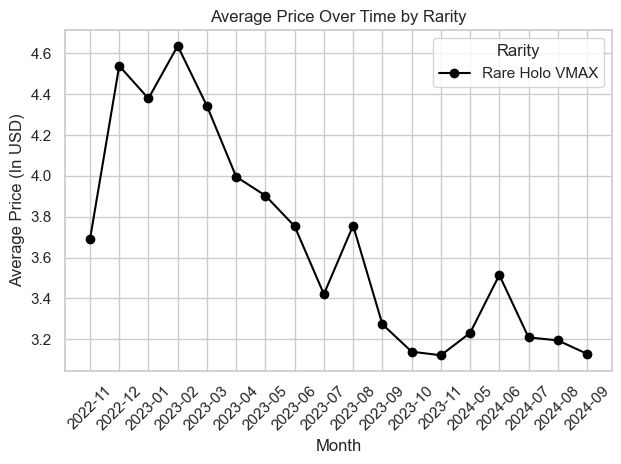

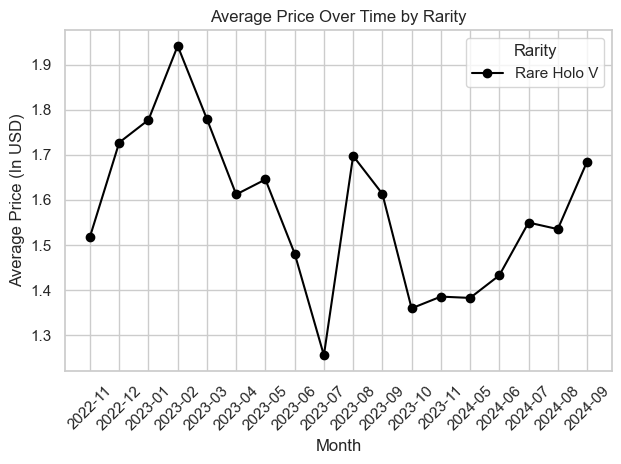

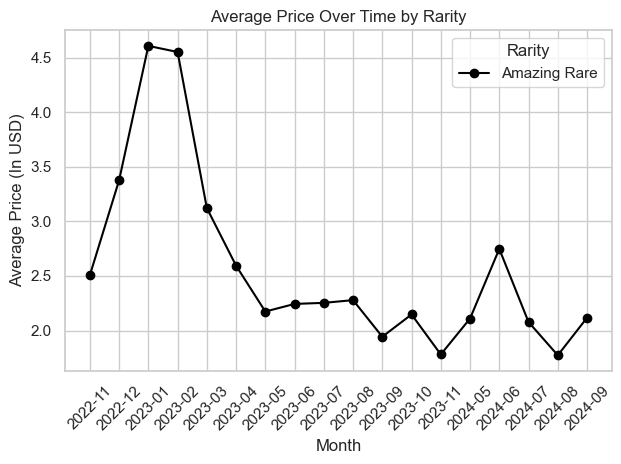

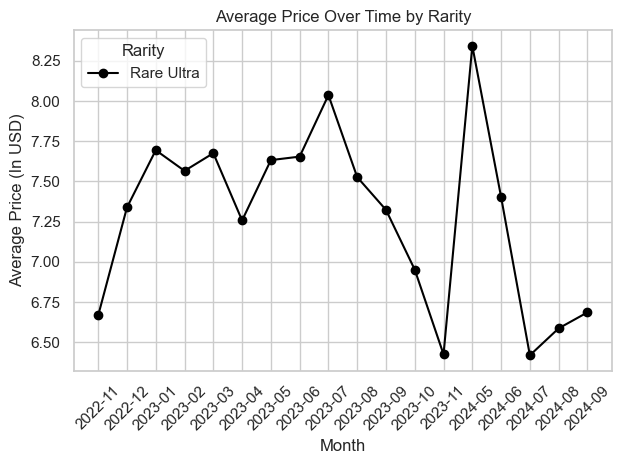

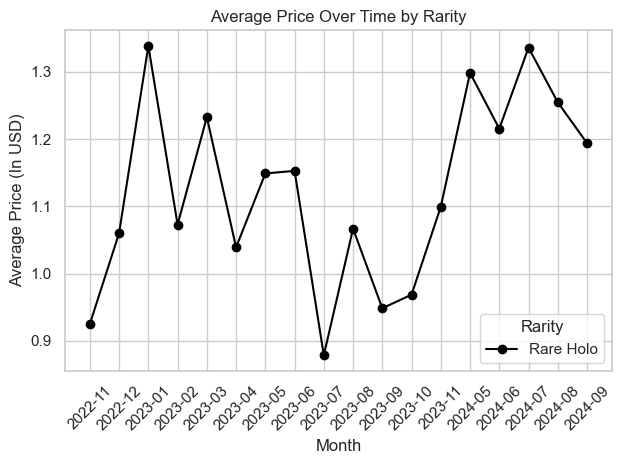

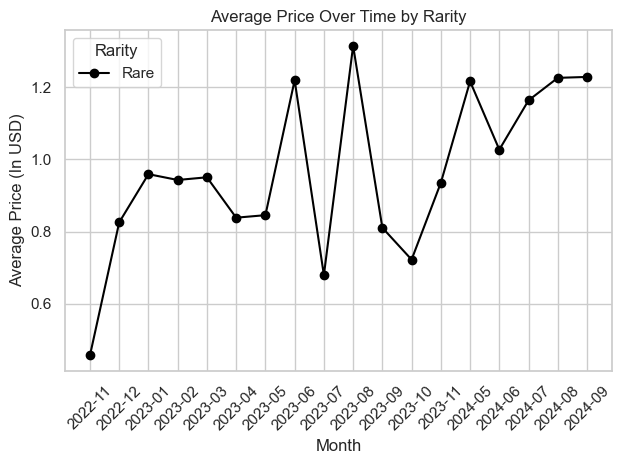

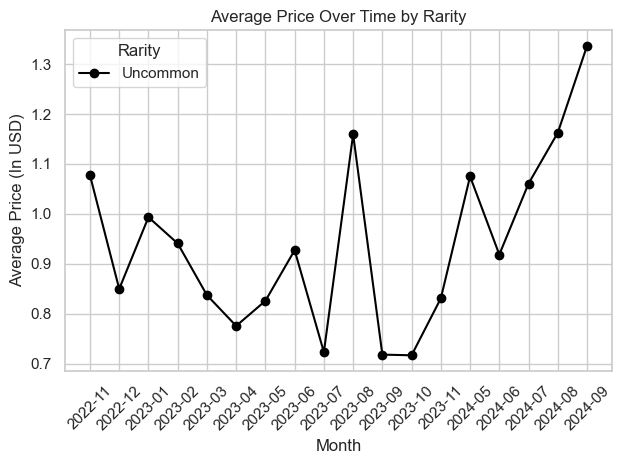

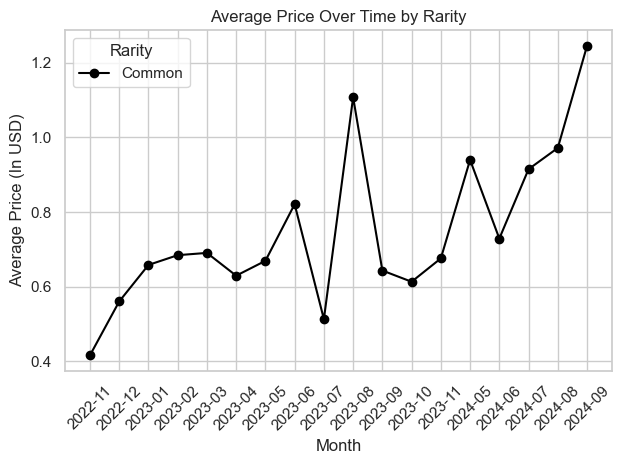

In [12]:
for rarity_df in dfs_by_rarity:
    # print(rarity_df.columns)
    # Find list of months
    months = rarity_df['Month'].unique()
    months = sorted(months)
    # print(months)
    # Iterate over df by month finding the average
    avg_by_month = []
    for month in months:
        month_df = rarity_df[rarity_df['Month'] == month]
        avg_by_month.append(month_df['Average'].mean())

    rarity = rarity_df.iloc[0]['Rarity']
    # lists = sorted(itertools.izip(*[]))
    # plt.figure()
    plt.plot(months, np.array(avg_by_month) / 100, label=rarity, marker='o', c='black')
    plt.title('Average Price Over Time by Rarity')
    plt.xticks(rotation=45)
    plt.xlabel('Month')
    plt.ylabel('Average Price (In USD)')
    plt.legend(title='Rarity')
    plt.grid(True)
    plt.tight_layout()
    plt.show()